## Imports

In [7]:
import polars as pl
import torch 
import random

print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Device: cuda


# Read and test/train split

In [3]:
df = pl.read_csv("../data/train.csv").select([
    "row_id", "sequence_type", "sequence_id", "sequence_counter", 
    "subject", "orientation", "behavior", "phase", "gesture",
    "acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"
])

In [14]:
# Train/test split (80/20) respetando series temporales
# Dividir por sequence_id para mantener la proporción 80/20

random.seed(42)

# Obtener los sequence_ids únicos
sequence_ids = df.select("sequence_id").unique().to_series().to_list()
random.shuffle(sequence_ids)

# Dividir sequence_ids 80/20
split_idx = int(len(sequence_ids) * 0.8)
train_sequence_ids = sequence_ids[:split_idx]
test_sequence_ids = sequence_ids[split_idx:]

# Filtrar el dataframe según los sequence_ids
train_df = df.filter(df["sequence_id"].is_in(train_sequence_ids))
test_df = df.filter(df["sequence_id"].is_in(test_sequence_ids))

print(f"Train sequence_ids: {len(train_sequence_ids)}, rows: {train_df.shape[0]}")
print(f"Test sequence_ids: {len(test_sequence_ids)}, rows: {test_df.shape[0]}")
print(f"Total sequence_ids: {len(sequence_ids)}, rows: {df.shape[0]}")
print(f"Train ratio: {train_df.shape[0] / df.shape[0] * 100:.1f}%")


Train sequence_ids: 6520, rows: 461354
Test sequence_ids: 1631, rows: 113591
Total sequence_ids: 8151, rows: 574945
Train ratio: 80.2%


In [15]:
# Validación: asegurar que no hay overlap de sequence_id entre train y test
train_sequence_ids = set(train_df.select("sequence_id").unique().to_series().to_list())
test_sequence_ids = set(test_df.select("sequence_id").unique().to_series().to_list())

overlap = train_sequence_ids.intersection(test_sequence_ids)

if len(overlap) == 0:
    print("✓ Validación exitosa: No hay overlap de sequence_id entre train y test")
else:
    print(f"✗ ERROR: {len(overlap)} sequence_ids aparecen en ambos conjuntos: {overlap}")

print(f"\nTrain sequence_ids únicos: {len(train_sequence_ids)}")
print(f"Test sequence_ids únicos: {len(test_sequence_ids)}")


✓ Validación exitosa: No hay overlap de sequence_id entre train y test

Train sequence_ids únicos: 6520
Test sequence_ids únicos: 1631


# Basic Models

In [16]:
# Preparación de datos para InceptionTime
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Seleccionar features para el modelo (7 sensores)
sensor_features = ["acc_x", "acc_y", "acc_z", "rot_w", "rot_x", "rot_y", "rot_z"]

# Agrupar datos por sequence_id para obtener series temporales
def create_sequences(df, features):
    """Convierte el dataframe agrupado por sequence_id en series temporales."""
    sequences = []
    labels = []
    
    for seq_id in df.select("sequence_id").unique().to_series():
        seq_data = df.filter(df["sequence_id"] == seq_id)
        
        # Obtener características y etiqueta
        X = seq_data.select(features).to_numpy().astype(np.float32)
        y = seq_data.select("gesture").to_series()[0]
        
        sequences.append(X)
        labels.append(y)
    
    return sequences, labels

# Crear sequences para train y test
train_sequences, train_labels = create_sequences(train_df, sensor_features)
test_sequences, test_labels = create_sequences(test_df, sensor_features)

print(f"Train: {len(train_sequences)} sequences")
print(f"Test: {len(test_sequences)} sequences")
print(f"Longitud de sequences (ejemplos):")
print(f"  Min: {min(len(s) for s in train_sequences)}, Max: {max(len(s) for s in train_sequences)}")
print(f"Clases únicas: {set(train_labels + test_labels)}")


Train: 6520 sequences
Test: 1631 sequences
Longitud de sequences (ejemplos):
  Min: 29, Max: 700
Clases únicas: {'Text on phone', 'Above ear - pull hair', 'Cheek - pinch skin', 'Feel around in tray and pull out an object', 'Wave hello', 'Pinch knee/leg skin', 'Glasses on/off', 'Eyelash - pull hair', 'Write name in air', 'Eyebrow - pull hair', 'Forehead - scratch', 'Drink from bottle/cup', 'Neck - pinch skin', 'Forehead - pull hairline', 'Scratch knee/leg skin', 'Pull air toward your face', 'Write name on leg', 'Neck - scratch'}


In [17]:
# Normalización y Padding de secuencias
from sklearn.preprocessing import StandardScaler

# Normalizar todas las sequences
scaler = StandardScaler()

# Fit del scaler en todo el train
all_train_data = np.concatenate(train_sequences, axis=0)
scaler.fit(all_train_data)

# Normalizar
train_sequences_scaled = [scaler.transform(s) for s in train_sequences]
test_sequences_scaled = [scaler.transform(s) for s in test_sequences]

# Padding/Truncate a longitud fija
max_length = max(len(s) for s in train_sequences_scaled + test_sequences_scaled)
print(f"Max length: {max_length}")

def pad_sequence(seq, max_len, pad_value=0):
    """Aplica padding o truncate a una secuencia."""
    if len(seq) >= max_len:
        return seq[:max_len]
    else:
        padding = np.full((max_len - len(seq), seq.shape[1]), pad_value, dtype=np.float32)
        return np.vstack([seq, padding])

# Aplicar padding
train_sequences_padded = np.array([pad_sequence(s, max_length) for s in train_sequences_scaled], dtype=np.float32)
test_sequences_padded = np.array([pad_sequence(s, max_length) for s in test_sequences_scaled], dtype=np.float32)

print(f"Train shape: {train_sequences_padded.shape}")  # (n_samples, max_length, n_features)
print(f"Test shape: {test_sequences_padded.shape}")

# Codificar labels
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

print(f"Classes: {le.classes_}")
print(f"Train labels: {np.unique(train_labels_encoded)}")


Max length: 700
Train shape: (6520, 700, 7)
Test shape: (1631, 700, 7)
Classes: ['Above ear - pull hair' 'Cheek - pinch skin' 'Drink from bottle/cup'
 'Eyebrow - pull hair' 'Eyelash - pull hair'
 'Feel around in tray and pull out an object' 'Forehead - pull hairline'
 'Forehead - scratch' 'Glasses on/off' 'Neck - pinch skin'
 'Neck - scratch' 'Pinch knee/leg skin' 'Pull air toward your face'
 'Scratch knee/leg skin' 'Text on phone' 'Wave hello' 'Write name in air'
 'Write name on leg']
Train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [18]:
# Dataset de PyTorch
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.from_numpy(sequences).float()
        self.labels = torch.from_numpy(labels).long()
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Retornar (batch_size, sequence_length, features)
        return self.sequences[idx], self.labels[idx]

# Crear datasets y dataloaders
train_dataset = TimeSeriesDataset(train_sequences_padded, train_labels_encoded)
test_dataset = TimeSeriesDataset(test_sequences_padded, test_labels_encoded)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Verificar una muestra
sample_x, sample_y = train_dataset[0]
print(f"Sample shape: {sample_x.shape}, label: {sample_y}")


Train batches: 204
Test batches: 51
Sample shape: torch.Size([700, 7]), label: 3


In [26]:
# Definir modelo InceptionTime
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[40, 20, 10]):
        super(InceptionModule, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[0], padding='same')
        self.conv2 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[1], padding='same')
        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_sizes[2], padding='same')
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')
        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (batch, in_channels, sequence_length)
        conv1_out = self.relu(self.conv1(x))
        conv2_out = self.relu(self.conv2(x))
        conv3_out = self.relu(self.conv3(x))
        pool_out = self.relu(self.conv_pool(self.maxpool(x)))
        
        # Concatenar en el eje del canal (todos tienen el mismo tamaño ahora)
        out = torch.cat([conv1_out, conv2_out, conv3_out, pool_out], dim=1)
        out = self.bn(out)
        return out

class InceptionTime(nn.Module):
    def __init__(self, in_channels, num_classes, num_inception_modules=3, bottleneck_channels=32):
        super(InceptionTime, self).__init__()
        
        self.inception_modules = nn.ModuleList()
        self.inception_modules.append(InceptionModule(in_channels, bottleneck_channels))
        
        for _ in range(num_inception_modules - 1):
            self.inception_modules.append(InceptionModule(bottleneck_channels * 4, bottleneck_channels))
        
        # Pooling adaptativo que mantiene información temporal
        # Reduce a 8 puntos temporales para evitar explosión de gradientes
        temporal_size = 8
        self.adaptive_pool = nn.AdaptiveAvgPool1d(temporal_size)
        
        # Fully connected layers con layer normalization
        self.fc_input_size = bottleneck_channels * 4 * temporal_size
        self.fc1 = nn.Linear(self.fc_input_size, 256)
        self.ln1 = nn.LayerNorm(256)
        self.fc2 = nn.Linear(256, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, 64)
        self.ln3 = nn.LayerNorm(64)
        self.fc4 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x shape: (batch, sequence_length, features)
        # Cambiar a (batch, features, sequence_length) para conv1d
        x = x.transpose(1, 2)
        
        for inception in self.inception_modules:
            x = inception(x)
        
        # Adaptive pooling mantiene información temporal
        # x shape: (batch, channels, sequence_length) -> (batch, channels, temporal_size)
        x = self.adaptive_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected con layer normalization
        x = self.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.ln3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        
        return x

# Inicializar modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionTime(
    in_channels=len(sensor_features),
    num_classes=len(le.classes_),
    num_inception_modules=3,
    bottleneck_channels=32
).to(device)

print(f"Modelo creado en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo creado en: cuda
Parámetros totales: 904,306


In [27]:
# Entrenar el modelo
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Learning rate más bajo para evitar NaN
num_epochs = 20
max_norm = 1.0  # Gradient clipping

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0.0
    train_preds = []
    train_true = []
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient clipping para evitar explosión de gradientes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        optimizer.step()
        
        train_loss += loss.item()
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_true.extend(batch_y.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_true.extend(batch_y.cpu().numpy())
    
    val_loss /= len(test_loader)
    val_acc = accuracy_score(val_true, val_preds)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

print("\nEntrenamiento completado")
print(f"Mejor accuracy de validación: {max(val_accs):.4f}")


Epoch 5/20
  Train Loss: nan, Acc: 0.0801
  Val Loss: nan, Acc: 0.0711
Epoch 10/20
  Train Loss: nan, Acc: 0.0801
  Val Loss: nan, Acc: 0.0711
Epoch 15/20
  Train Loss: nan, Acc: 0.0801
  Val Loss: nan, Acc: 0.0711
Epoch 20/20
  Train Loss: nan, Acc: 0.0801
  Val Loss: nan, Acc: 0.0711

Entrenamiento completado
Mejor accuracy de validación: 0.0711


Accuracy en test: 0.0711

Classification Report:
                                            precision    recall  f1-score   support

                     Above ear - pull hair       0.07      1.00      0.13       116
                        Cheek - pinch skin       0.00      0.00      0.00       138
                     Drink from bottle/cup       0.00      0.00      0.00        31
                       Eyebrow - pull hair       0.00      0.00      0.00       141
                       Eyelash - pull hair       0.00      0.00      0.00       134
Feel around in tray and pull out an object       0.00      0.00      0.00        38
                  Forehead - pull hairline       0.00      0.00      0.00       130
                        Forehead - scratch       0.00      0.00      0.00       120
                            Glasses on/off       0.00      0.00      0.00        33
                         Neck - pinch skin       0.00      0.00      0.00       143
                          

/home/rodri/master/detect_behavior_competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rodri/master/detect_behavior_competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rodri/master/detect_behavior_competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

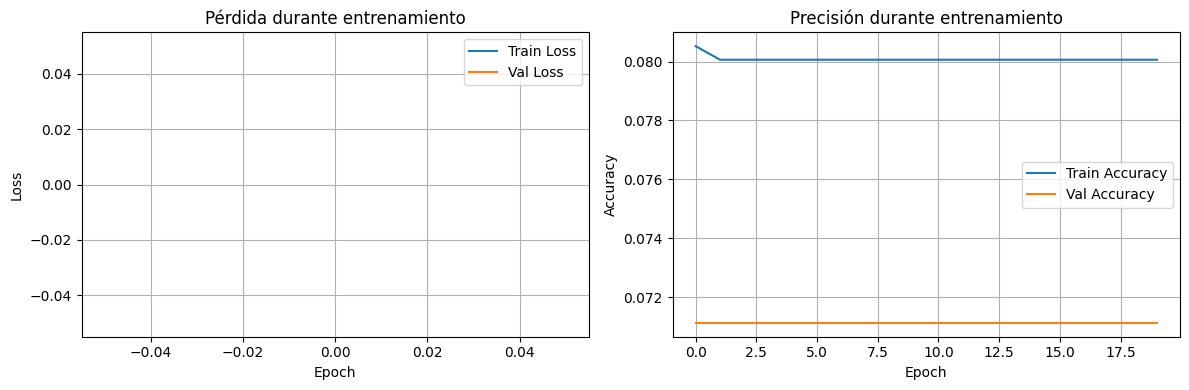

In [23]:
# Evaluación final y reportes
import matplotlib.pyplot as plt

# Evaluar en test
model.eval()
test_preds = []
test_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_true.extend(batch_y.cpu().numpy())

test_acc = accuracy_score(test_true, test_preds)
print(f"Accuracy en test: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(test_true, test_preds, target_names=le.classes_))

# Graficar curvas de pérdida y precisión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdida durante entrenamiento")
axes[0].legend()
axes[0].grid()

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(val_accs, label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Precisión durante entrenamiento")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()
